# Plot-level sugarcane trait prediction from Jilin-1 imagery — SVR model-selection pipeline

**Paper:** *Integrating spectral, texture, soil and fertilization information for plot-level prediction of sugarcane yield, millable stalk population and Brix from Jilin-1 imagery* (Research Square preprint rs-9371174/v1, DOI 10.21203/rs.3.rs-9371174/v1).

**Author code:** [guangtaoxu08-dev/SPT_JL](https://github.com/guangtaoxu08-dev/SPT_JL) pinned at commit `027f25a7abab485b95419f949977b6fe8ddaeaaa` (SVR_Model.py, verified 2026-10-06).

**Scope of this notebook (partial demonstration):** run the authors' released SVR training script — SVR-RFE feature selection, leave-one-out cross-validation (LOOCV), and grid-search hyperparameter tuning — on the repository's bundled `data_test.xlsx`. This exercises the paper's model-selection pipeline (Sections 2.3–2.4) on a minimal input.

**重要な制限 / Important limitation:** the authors state that `data_test.xlsx` is *random test data for model and code testing only*. Therefore the metrics computed here are **not comparable to the paper's reported results** (e.g. yield R²CV = 0.70), which require the real plot-level VI/TI/soil/fertilization dataset and commercial Jilin-1 imagery that cannot be redistributed.

**含まれない範囲 / Not covered:** Jilin-1 scene acquisition (jl1mall.com), ENVI/GEE preprocessing, RR/GPR/CatBoost comparison, SHAP analysis, and prediction mapping.

**ランタイム / Runtime:** CPU only (scikit-learn on a small table; no GPU is used).

## 1. Setup

The author script depends only on `pandas`, `numpy`, `scikit-learn` and `openpyxl` (for `.xlsx` reading). We pin nothing beyond what the script itself imports, and record library versions for provenance.

In [ ]:
%pip install -q openpyxl

import numpy, pandas, sklearn, openpyxl, sys
print("python", sys.version.split()[0])
print("numpy", numpy.__version__)
print("pandas", pandas.__version__)
print("scikit-learn", sklearn.__version__)
print("openpyxl", openpyxl.__version__)

python 3.13.16
numpy 2.1.3
pandas 2.2.3
scikit-learn 1.6.1
openpyxl 3.1.5


## 2. Download the pinned inputs (inside Colab)

We fetch exactly two files from the pinned commit `027f25a7abab485b95419f949977b6fe8ddaeaaa`:

- `data_test.xlsx` — the bundled (random) test input, expected Git blob SHA-1 `1678e1cd25c513b4406b5633a6a1bcc41be9447d`, 17127 bytes;
- `SVR_Model.py` — the author training script, expected blob SHA-1 `aaf2fc187cb8e3e566499ff229c08b2b6b7a2edc`, 3856 bytes.

Each download is verified against the Git blob hash (`sha1("blob <size>\\0" + content)`), so a truncated or altered file is rejected. The script expects its input in a `data/` subfolder, so we place the workbook there exactly as the script requires.

In [ ]:
import hashlib, pathlib, urllib.request

COMMIT = "027f25a7abab485b95419f949977b6fe8ddaeaaa"
BASE = f"https://raw.githubusercontent.com/guangtaoxu08-dev/SPT_JL/{COMMIT}"

EXPECTED = {
    "data_test.xlsx": ("1678e1cd25c513b4406b5633a6a1bcc41be9447d", 17127),
    "SVR_Model.py": ("aaf2fc187cb8e3e566499ff229c08b2b6b7a2edc", 3856),
}

work = pathlib.Path("/content/spt_jl"); work.mkdir(exist_ok=True)

def git_blob_sha(b: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(b) + b).hexdigest()

for name, (want_sha, want_size) in EXPECTED.items():
    url = f"{BASE}/{name}"
    raw = urllib.request.urlopen(url, timeout=120).read()
    assert len(raw) == want_size, f"{name}: size {len(raw)} != {want_size}"
    got = git_blob_sha(raw)
    assert got == want_sha, f"{name}: blob sha {got} != {want_sha}"
    dest = work / name if name.endswith(".py") else work / "data" / name
    dest.parent.mkdir(exist_ok=True)
    dest.write_bytes(raw)
    print(f"OK {name}: {len(raw)} bytes, git blob sha {got} -> {dest}")

OK data_test.xlsx: 17127 bytes, git blob sha 1678e1cd25c513b4406b5633a6a1bcc41be9447d -> /content/spt_jl/data/data_test.xlsx


OK SVR_Model.py: 3856 bytes, git blob sha aaf2fc187cb8e3e566499ff229c08b2b6b7a2edc -> /content/spt_jl/SVR_Model.py


## 3. Inspect the input table

Before running the model we look at the shape and columns of `data_test.xlsx`. The author script treats **column 0** as an identifier, **columns 1..-2** as predictors (X) and the **last column** as the target (y).

In [ ]:
import pandas as pd

df = pd.read_excel("/content/spt_jl/data/data_test.xlsx")
print("shape:", df.shape)
print("columns:", list(df.columns))
df.head()

shape: (20, 19)
columns: ['FID', 'CI', 'CVI', 'GBNDVI', 'GLI', 'GNDVI', 'RVI', 'DDRTI_ASM(B,NIR,G,R)', 'DDRTI_CON(G,NIR,B,R)', 'DDRTI_COR(B,R,G,NIR)', 'DDRTI_DIS(G,NIR,B,R)', 'DDRTI_MEA(B,G,NIR,R)', 'EVTI_CON(R,G,NIR)', 'EVTI_COR(B,G,R)', 'EVTI_HOM(R,NIR,B)', 'EVTI_VAR(R,G,NIR)', 'NDTI_COR(B,R)', 'NDTI_MEA(B,G)', 'Yield']


,FID,CI,CVI,GBNDVI,GLI,GNDVI,RVI,"DDRTI_ASM(B,NIR,G,R)","DDRTI_CON(G,NIR,B,R)","DDRTI_COR(B,R,G,NIR)","DDRTI_DIS(G,NIR,B,R)","DDRTI_MEA(B,G,NIR,R)","EVTI_CON(R,G,NIR)","EVTI_COR(B,G,R)","EVTI_HOM(R,NIR,B)","EVTI_VAR(R,G,NIR)","NDTI_COR(B,R)","NDTI_MEA(B,G)",Yield
0,1,0.463252,4.942981,0.622251,0.238334,0.719903,7.926999,-0.249974,0.528314,-0.102248,0.337904,0.152430,-0.077251,-1.076530,-0.394314,-0.012546,-0.106501,0.239123,60.255450
1,2,0.426922,4.781035,0.610154,0.231502,0.714392,7.722333,-0.905031,0.591638,-0.177059,0.411245,0.151386,-0.112284,-3.262526,-0.240852,0.001262,-0.198379,0.221562,62.874698
2,3,0.415841,4.218686,0.528743,0.187828,0.659561,5.714360,-0.930737,0.609080,-0.183853,0.442216,0.097520,-0.144249,1.547983,-0.244905,-0.007904,-0.203874,0.107618,71.134279
3,4,0.411104,4.385263,0.548150,0.195142,0.674315,6.218097,-0.935275,0.720812,-0.041266,0.481748,0.121325,-0.137077,-0.182498,-0.304338,-0.109920,-0.039531,0.139412,102.205780
4,5,0.397538,4.323605,0.533996,0.184128,0.666573,5.978535,-0.770283,0.702920,-0.070435,0.445014,0.132908,-0.131672,-0.489227,-0.288407,-0.074576,-0.069544,0.150113,86.397287


## 4. Run the author's SVR_Model.py verbatim

We execute the downloaded `SVR_Model.py` **unmodified** from the pinned commit. Two faithful-run notes:

1. The script is **silent on success**: `results_summary` is initialized but never appended to, and the file ends after computing `test_rpd` without printing. A successful run therefore produces no output — that is the authors' released behavior, not an error.
2. To make the computed model-selection results visible without altering the script, we execute it in an explicit namespace and then read the metrics (`test_r2`, `test_rmse`, `test_rpd`, best feature subset, best hyperparameters) from that namespace.

パイプラインの流れ: 標準化 → SVR(線形)を推定器とした RFE による特徴量数 1〜N の各サブセット選択（各サブセットを LOOCV の平均 MSE で評価）→ 最良サブセット上でグリッドサーチ（C: 50 点対数スケール × epsilon: 50 点 × 4 カーネル, 5 折 CV, R² スコア）→ 最良モデルで再度 LOOCV を実施し R²/RMSE/RPD を算出。

In [ ]:
script_src = pathlib.Path("/content/spt_jl/SVR_Model.py").read_text()
ns = {"__file__": str(pathlib.Path("/content/spt_jl/SVR_Model.py").resolve()), "__name__": "__main__"}
exec(compile(script_src, "SVR_Model.py", "exec"), ns)

print("=== Author SVR_Model.py on data_test.xlsx (random test data) ===")
print("selected features (n=%d):" % len(ns["selected_feature_names"]), ns["selected_feature_names"])
print("grid-search best params:", ns["grid_search"].best_params_)
print("grid-search best CV R2 (scaled y):", round(ns["grid_search"].best_score_, 4))
print("train R2 / RMSE:", ns["train_r2"], "/", ns["train_rmse"])
print("LOOCV test R2 / RMSE / RPD:", ns["test_r2"], "/", ns["test_rmse"], "/", ns["test_rpd"])

=== Author SVR_Model.py on data_test.xlsx (random test data) ===
selected features (n=2): ['GNDVI', 'EVTI_COR(B,G,R)']
grid-search best params: {'C': np.float64(1.151395399326447), 'epsilon': np.float64(0.3736734693877551), 'kernel': 'rbf'}
grid-search best CV R2 (scaled y): 0.3281
train R2 / RMSE: 0.72 / 10.52
LOOCV test R2 / RMSE / RPD: 0.46 / 14.48 / 1.36


## 5. Interpretation and limitations

- The numbers above describe the pipeline's behavior on **random test data only**. They validate that the authors' released code runs end-to-end (RFE subset search → grid search → LOOCV evaluation), not the paper's scientific claims.
- In the paper, the same SVR pipeline (with RR/GPR/CatBoost comparison, SHAP, and bootstrap verification) is applied to real plot-level vegetation-index, texture-index, soil and fertilization features extracted from commercial Jilin-1 imagery; those inputs cannot be reproduced from open assets.
- ライセンス: リポジトリに LICENSE ファイルは存在しないため、再利用条件は要確認です。

The executed example and the checks above were validated in a fresh Colab CPU runtime; untested behavior of the script beyond this path is not guaranteed.

## 6. Preview placeholder (data-only scope)

This reproduction is table-only: it produces metrics but no image or graph. Following the publication convention, a plain placeholder is shown instead of a scientific figure.

*No image or graph generated for this data-only reproduction.*

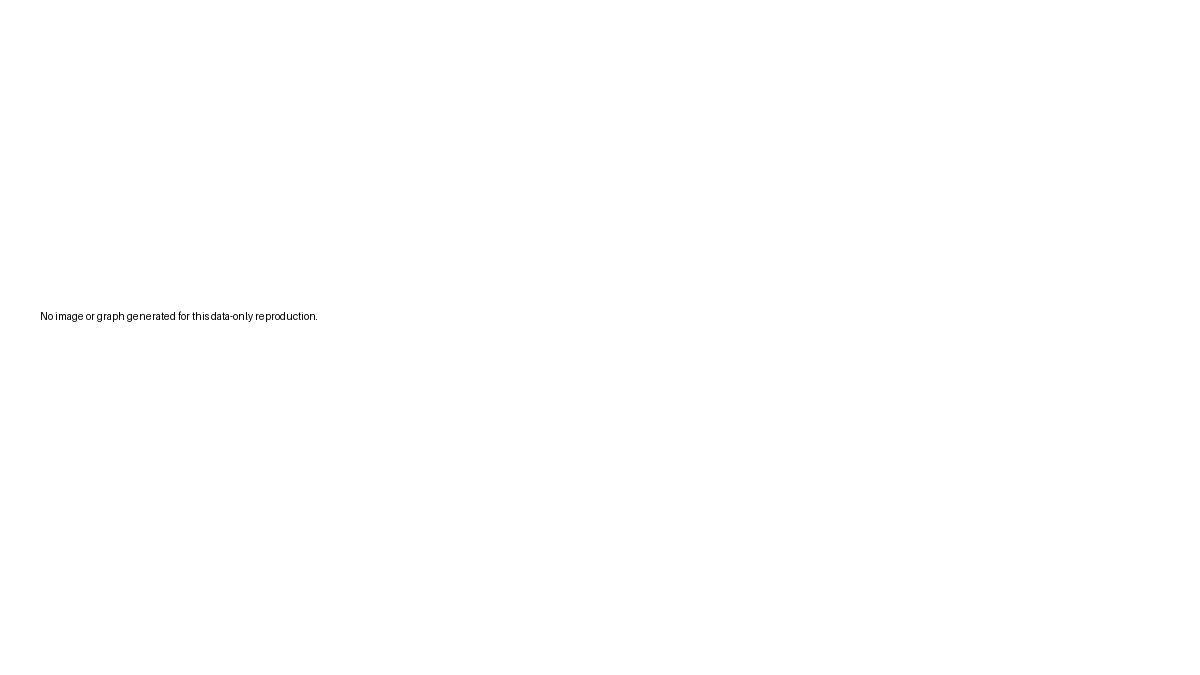

In [ ]:
from PIL import Image, ImageDraw
img = Image.new("RGB", (1200, 675), "white")
d = ImageDraw.Draw(img)
d.text((40, 310), "No image or graph generated for this data-only reproduction.", fill="black")
img.save("/content/preview_placeholder.png")
img